# Data Munging with Python
**Complete End-to-End Analysis — Beginner Friendly**

This notebook is a Python translation of the R tidyverse data munging script.
We use: `numpy`, `pandas`, `scikit-learn`, `matplotlib`, and `seaborn`.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Make plots look nice
sns.set_theme(style='whitegrid')
print('All libraries imported!')

All libraries imported!


## 2. Create the Messy Employee Dataset
This is our raw, messy data — just like real-world data.

In [2]:
employees = pd.DataFrame({
    'employee_id': [101, 102, 103, 104, 105, 103, 106, 107],

    'name': [
        'Ali Khan',
        ' Sara Ahmed ',   # extra spaces
        'Ahmed Raza',
        'Fatima Noor',
        'Usman Ali',
        'Ahmed Raza',     # duplicate!
        'Ayesha Malik',
        'Bilal Shah'
    ],

    'age': [25, np.nan, 32, 29, 41, 32, 27, 35],  # np.nan = missing

    'gender': ['M', 'Female', 'Male', 'F', 'male', 'Male', 'F', 'MALE'],  # inconsistent!

    'salary': ['50000', '$60,000', '55000', None, '85000', '55000', '65000', '$72,000'],  # messy strings!

    'department': ['IT', 'HR', 'it', 'Finance', 'HR ', 'it', 'FINANCE', ' Hr']  # inconsistent cases!
})

employees

,employee_id,name,age,gender,salary,department
0,101,Ali Khan,25.0,M,50000,IT
1,102,Sara Ahmed,NaN,Female,"$60,000",HR
2,103,Ahmed Raza,32.0,Male,55000,it
3,104,Fatima Noor,29.0,F,NaN,Finance
4,105,Usman Ali,41.0,male,85000,HR
5,103,Ahmed Raza,32.0,Male,55000,it
6,106,Ayesha Malik,27.0,F,65000,FINANCE
7,107,Bilal Shah,35.0,MALE,"$72,000",Hr


## 3. Inspect the Raw Dataset

In [3]:
# First 5 rows
print('--- First 5 rows ---')
print(employees.head())

print('\n--- Last 5 rows ---')
print(employees.tail())

print('\n--- Shape (rows, columns) ---')
print(employees.shape)

print('\n--- Column names ---')
print(employees.columns.tolist())

print('\n--- Data types (like str() in R) ---')
print(employees.dtypes)

print('\n--- Summary statistics ---')
print(employees.describe(include='all'))

--- First 5 rows ---
   employee_id          name   age  gender   salary department
0          101      Ali Khan  25.0       M    50000         IT
1          102   Sara Ahmed    NaN  Female  $60,000         HR
2          103    Ahmed Raza  32.0    Male    55000         it
3          104   Fatima Noor  29.0       F      NaN    Finance
4          105     Usman Ali  41.0    male    85000        HR 

--- Last 5 rows ---
   employee_id          name   age gender   salary department
3          104   Fatima Noor  29.0      F      NaN    Finance
4          105     Usman Ali  41.0   male    85000        HR 
5          103    Ahmed Raza  32.0   Male    55000         it
6          106  Ayesha Malik  27.0      F    65000    FINANCE
7          107    Bilal Shah  35.0   MALE  $72,000         Hr

--- Shape (rows, columns) ---
(8, 6)

--- Column names ---
['employee_id', 'name', 'age', 'gender', 'salary', 'department']

--- Data types (like str() in R) ---
employee_id      int64
name               str

## 4. Identify Missing Values

In [4]:
# True/False table of missing values
print('--- Missing value map ---')
print(employees.isnull())

print('\n--- Total missing values ---')
print(employees.isnull().sum().sum())

print('\n--- Missing values per column ---')
print(employees.isnull().sum())

print('\n--- Rows that have at least one missing value ---')
print(employees[employees.isnull().any(axis=1)])

--- Missing value map ---
   employee_id   name    age  gender  salary  department
0        False  False  False   False   False       False
1        False  False   True   False   False       False
2        False  False  False   False   False       False
3        False  False  False   False    True       False
4        False  False  False   False   False       False
5        False  False  False   False   False       False
6        False  False  False   False   False       False
7        False  False  False   False   False       False

--- Total missing values ---
2

--- Missing values per column ---
employee_id    0
name           0
age            1
gender         0
salary         1
department     0
dtype: int64

--- Rows that have at least one missing value ---
   employee_id          name   age  gender   salary department
1          102   Sara Ahmed    NaN  Female  $60,000         HR
3          104   Fatima Noor  29.0       F      NaN    Finance


## 5. Identify Duplicate Records

In [5]:
# Check which rows are duplicates
print('--- Duplicate row flags ---')
print(employees.duplicated())

print('\n--- Number of duplicate rows ---')
print(employees.duplicated().sum())

print('\n--- Show duplicate rows ---')
print(employees[employees.duplicated()])

print('\n--- Duplicate employee_ids ---')
dup_ids = employees['employee_id'].value_counts()
print(dup_ids[dup_ids > 1])

--- Duplicate row flags ---
0    False
1    False
2    False
3    False
4    False
5     True
6    False
7    False
dtype: bool

--- Number of duplicate rows ---
1

--- Show duplicate rows ---
   employee_id        name   age gender salary department
5          103  Ahmed Raza  32.0   Male  55000         it

--- Duplicate employee_ids ---
employee_id
103    2
Name: count, dtype: int64


## 6. Remove Duplicate Employees

In [6]:
# Keep only first occurrence of each employee_id
employees = employees.drop_duplicates(subset='employee_id', keep='first')

# Reset the row index numbers
employees = employees.reset_index(drop=True)

print('After removing duplicates:')
print(employees)

After removing duplicates:
   employee_id          name   age  gender   salary department
0          101      Ali Khan  25.0       M    50000         IT
1          102   Sara Ahmed    NaN  Female  $60,000         HR
2          103    Ahmed Raza  32.0    Male    55000         it
3          104   Fatima Noor  29.0       F      NaN    Finance
4          105     Usman Ali  41.0    male    85000        HR 
5          106  Ayesha Malik  27.0       F    65000    FINANCE
6          107    Bilal Shah  35.0    MALE  $72,000         Hr


## 7. Clean Employee Names (Remove Extra Spaces)

In [7]:
# .str.strip() is like str_trim() in R
employees['name'] = employees['name'].str.strip()

print('Clean names:')
print(employees['name'].tolist())

Clean names:
['Ali Khan', 'Sara Ahmed', 'Ahmed Raza', 'Fatima Noor', 'Usman Ali', 'Ayesha Malik', 'Bilal Shah']


## 8. Standardize Gender

In [8]:
# Map all variations to 'Male' or 'Female'
male_values   = ['M', 'Male', 'male', 'MALE']
female_values = ['F', 'Female', 'female', 'FEMALE']

def standardize_gender(value):
    if value in male_values:
        return 'Male'
    elif value in female_values:
        return 'Female'
    else:
        return np.nan

employees['gender'] = employees['gender'].apply(standardize_gender)

print('Unique gender values after cleaning:')
print(employees['gender'].unique())

print('\nCount by gender:')
print(employees['gender'].value_counts())

Unique gender values after cleaning:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Count by gender:
gender
Male      4
Female    3
Name: count, dtype: int64


## 9. Standardize Department Names

In [9]:
# Step 1: Remove spaces
employees['department'] = employees['department'].str.strip()

# Step 2: Map to standard names using lowercase comparison
def standardize_dept(value):
    v = value.lower()
    if v == 'it':
        return 'IT'
    elif v == 'hr':
        return 'HR'
    elif v == 'finance':
        return 'Finance'
    else:
        return value

employees['department'] = employees['department'].apply(standardize_dept)

print('Unique departments after cleaning:')
print(employees['department'].unique())

Unique departments after cleaning:
<StringArray>
['IT', 'HR', 'Finance']
Length: 3, dtype: str


## 10. Convert Salary from String to Number

In [10]:
print('Before cleaning:')
print(employees['salary'])

# Remove '$' and ',' then convert to float
employees['salary'] = (
    employees['salary']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print('\nAfter cleaning:')
print(employees['salary'])
print('\nData type:', employees['salary'].dtype)

Before cleaning:
0      50000
1    $60,000
2      55000
3        NaN
4      85000
5      65000
6    $72,000
Name: salary, dtype: str

After cleaning:
0    50000.0
1    60000.0
2    55000.0
3        NaN
4    85000.0
5    65000.0
6    72000.0
Name: salary, dtype: float64

Data type: float64


## 11. Handle Missing Age (Fill with Median)

In [11]:
age_median = employees['age'].median()
print('Median age:', age_median)

# Fill missing age with median
employees['age'] = employees['age'].fillna(age_median)

print('\nAges after filling:')
print(employees['age'].tolist())

Median age: 30.5

Ages after filling:
[25.0, 30.5, 32.0, 29.0, 41.0, 27.0, 35.0]


## 12. Handle Missing Salary (Fill with Department Median)

In [12]:
# Fill missing salary using each department's own median
employees['salary'] = employees.groupby('department')['salary'].transform(
    lambda x: x.fillna(x.median())
)

# Check: any salary still missing?
print('Missing salaries after fill:', employees['salary'].isnull().sum())
print(employees[['name', 'department', 'salary']])

Missing salaries after fill: 0
           name department   salary
0      Ali Khan         IT  50000.0
1    Sara Ahmed         HR  60000.0
2    Ahmed Raza         IT  55000.0
3   Fatima Noor    Finance  65000.0
4     Usman Ali         HR  85000.0
5  Ayesha Malik    Finance  65000.0
6    Bilal Shah         HR  72000.0


## 13. Create Monthly Salary

In [13]:
employees['monthly_salary'] = employees['salary'] / 12

print(employees[['employee_id', 'name', 'salary', 'monthly_salary']])

   employee_id          name   salary  monthly_salary
0          101      Ali Khan  50000.0     4166.666667
1          102    Sara Ahmed  60000.0     5000.000000
2          103    Ahmed Raza  55000.0     4583.333333
3          104   Fatima Noor  65000.0     5416.666667
4          105     Usman Ali  85000.0     7083.333333
5          106  Ayesha Malik  65000.0     5416.666667
6          107    Bilal Shah  72000.0     6000.000000


## 14. Create Salary Categories

In [14]:
# Like case_when() in R
def salary_category(salary):
    if salary < 50000:
        return 'Low'
    elif salary < 70000:
        return 'Medium'
    else:
        return 'High'

employees['salary_category'] = employees['salary'].apply(salary_category)

print('Salary category counts:')
print(employees['salary_category'].value_counts())

Salary category counts:
salary_category
Medium    5
High      2
Name: count, dtype: int64


## 15. Create Age Groups

In [15]:
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 40:
        return 'Mid-career'
    else:
        return 'Senior'

employees['age_group'] = employees['age'].apply(age_group)

print('Age group counts:')
print(employees['age_group'].value_counts())

Age group counts:
age_group
Young         3
Mid-career    3
Senior        1
Name: count, dtype: int64


## 16. Select Columns

In [16]:
# Select specific columns
print('--- Selected columns ---')
print(employees[['employee_id', 'name', 'age', 'gender', 'salary']])

# Drop a column
print('\n--- All columns except gender ---')
print(employees.drop(columns=['gender']))

# Columns that start with 'salary'
salary_cols = [col for col in employees.columns if col.startswith('salary')]
print('\n--- Salary columns ---')
print(employees[salary_cols])

--- Selected columns ---
   employee_id          name   age  gender   salary
0          101      Ali Khan  25.0    Male  50000.0
1          102    Sara Ahmed  30.5  Female  60000.0
2          103    Ahmed Raza  32.0    Male  55000.0
3          104   Fatima Noor  29.0  Female  65000.0
4          105     Usman Ali  41.0    Male  85000.0
5          106  Ayesha Malik  27.0  Female  65000.0
6          107    Bilal Shah  35.0    Male  72000.0

--- All columns except gender ---
   employee_id          name   age   salary department  monthly_salary  \
0          101      Ali Khan  25.0  50000.0         IT     4166.666667   
1          102    Sara Ahmed  30.5  60000.0         HR     5000.000000   
2          103    Ahmed Raza  32.0  55000.0         IT     4583.333333   
3          104   Fatima Noor  29.0  65000.0    Finance     5416.666667   
4          105     Usman Ali  41.0  85000.0         HR     7083.333333   
5          106  Ayesha Malik  27.0  65000.0    Finance     5416.666667   
6     

## 17. Filter Observations

In [17]:
print('--- Employees older than 30 ---')
print(employees[employees['age'] > 30])

print('\n--- Salary above 60,000 ---')
print(employees[employees['salary'] > 60000])

print('\n--- IT department only ---')
print(employees[employees['department'] == 'IT'])

print('\n--- HR with salary > 50,000 ---')
print(employees[(employees['department'] == 'HR') & (employees['salary'] > 50000)])

print('\n--- IT or HR ---')
print(employees[employees['department'].isin(['IT', 'HR'])])

--- Employees older than 30 ---
   employee_id        name   age  gender   salary department  monthly_salary  \
1          102  Sara Ahmed  30.5  Female  60000.0         HR     5000.000000   
2          103  Ahmed Raza  32.0    Male  55000.0         IT     4583.333333   
4          105   Usman Ali  41.0    Male  85000.0         HR     7083.333333   
6          107  Bilal Shah  35.0    Male  72000.0         HR     6000.000000   

  salary_category   age_group  
1          Medium  Mid-career  
2          Medium  Mid-career  
4            High      Senior  
6            High  Mid-career  

--- Salary above 60,000 ---
   employee_id          name   age  gender   salary department  \
3          104   Fatima Noor  29.0  Female  65000.0    Finance   
4          105     Usman Ali  41.0    Male  85000.0         HR   
5          106  Ayesha Malik  27.0  Female  65000.0    Finance   
6          107    Bilal Shah  35.0    Male  72000.0         HR   

   monthly_salary salary_category   age_group  

## 18. Sort Observations

In [18]:
print('--- Lowest salary first ---')
print(employees.sort_values('salary'))

print('\n--- Highest salary first ---')
print(employees.sort_values('salary', ascending=False))

print('\n--- By department, then salary (desc) ---')
print(employees.sort_values(['department', 'salary'], ascending=[True, False]))

--- Lowest salary first ---
   employee_id          name   age  gender   salary department  \
0          101      Ali Khan  25.0    Male  50000.0         IT   
2          103    Ahmed Raza  32.0    Male  55000.0         IT   
1          102    Sara Ahmed  30.5  Female  60000.0         HR   
3          104   Fatima Noor  29.0  Female  65000.0    Finance   
5          106  Ayesha Malik  27.0  Female  65000.0    Finance   
6          107    Bilal Shah  35.0    Male  72000.0         HR   
4          105     Usman Ali  41.0    Male  85000.0         HR   

   monthly_salary salary_category   age_group  
0     4166.666667          Medium       Young  
2     4583.333333          Medium  Mid-career  
1     5000.000000          Medium  Mid-career  
3     5416.666667          Medium       Young  
5     5416.666667          Medium       Young  
6     6000.000000            High  Mid-career  
4     7083.333333            High      Senior  

--- Highest salary first ---
   employee_id          name 

## 19. Count Employees

In [19]:
print('Total employees:', len(employees))

print('\n--- By department ---')
print(employees['department'].value_counts())

print('\n--- By gender ---')
print(employees['gender'].value_counts())

print('\n--- By department AND gender ---')
print(employees.groupby(['department', 'gender']).size().reset_index(name='count'))

Total employees: 7

--- By department ---
department
HR         3
IT         2
Finance    2
Name: count, dtype: int64

--- By gender ---
gender
Male      4
Female    3
Name: count, dtype: int64

--- By department AND gender ---
  department  gender  count
0    Finance  Female      2
1         HR  Female      1
2         HR    Male      2
3         IT    Male      2


## 20. Calculate Summary Statistics

In [20]:
print('Average salary:', employees['salary'].mean())

print('\n--- Multiple stats ---')
stats = {
    'employees'     : len(employees),
    'average_salary': employees['salary'].mean(),
    'median_salary' : employees['salary'].median(),
    'min_salary'    : employees['salary'].min(),
    'max_salary'    : employees['salary'].max(),
    'total_salary'  : employees['salary'].sum()
}
for key, val in stats.items():
    print(f'  {key}: {val}')

Average salary: 64571.42857142857

--- Multiple stats ---
  employees: 7
  average_salary: 64571.42857142857
  median_salary: 65000.0
  min_salary: 50000.0
  max_salary: 85000.0
  total_salary: 452000.0


## 21. Salary by Department

In [21]:
department_summary = employees.groupby('department').agg(
    employees      = ('salary', 'count'),
    average_salary = ('salary', 'mean'),
    median_salary  = ('salary', 'median'),
    min_salary     = ('salary', 'min'),
    max_salary     = ('salary', 'max'),
    total_salary   = ('salary', 'sum')
).reset_index().sort_values('average_salary', ascending=False)

print(department_summary)

  department  employees  average_salary  median_salary  min_salary  \
1         HR          3    72333.333333        72000.0     60000.0   
0    Finance          2    65000.000000        65000.0     65000.0   
2         IT          2    52500.000000        52500.0     50000.0   

   max_salary  total_salary  
1     85000.0      217000.0  
0     65000.0      130000.0  
2     55000.0      105000.0  


## 22. Salary by Gender

In [22]:
gender_summary = employees.groupby('gender').agg(
    employees      = ('salary', 'count'),
    average_salary = ('salary', 'mean'),
    median_salary  = ('salary', 'median')
).reset_index()

print(gender_summary)

   gender  employees  average_salary  median_salary
0  Female          3    63333.333333        65000.0
1    Male          4    65500.000000        63500.0


## 23. Department + Gender Analysis

In [23]:
dept_gender = employees.groupby(['department', 'gender']).agg(
    employees      = ('salary', 'count'),
    average_salary = ('salary', 'mean')
).reset_index()

print(dept_gender)

  department  gender  employees  average_salary
0    Finance  Female          2         65000.0
1         HR  Female          1         60000.0
2         HR    Male          2         78500.0
3         IT    Male          2         52500.0


## 24. Build a Clean Pipeline

In [24]:
# Like the pipe (%>%) chain in R
employees_clean = (
    employees
    [employees['age'] >= 18]                         # filter
    .assign(monthly_salary=lambda df: df['salary'] / 12)  # mutate
    .sort_values('salary', ascending=False)           # arrange desc
    .reset_index(drop=True)
)

print(employees_clean)

   employee_id          name   age  gender   salary department  \
0          105     Usman Ali  41.0    Male  85000.0         HR   
1          107    Bilal Shah  35.0    Male  72000.0         HR   
2          104   Fatima Noor  29.0  Female  65000.0    Finance   
3          106  Ayesha Malik  27.0  Female  65000.0    Finance   
4          102    Sara Ahmed  30.5  Female  60000.0         HR   
5          103    Ahmed Raza  32.0    Male  55000.0         IT   
6          101      Ali Khan  25.0    Male  50000.0         IT   

   monthly_salary salary_category   age_group  
0     7083.333333            High      Senior  
1     6000.000000            High  Mid-career  
2     5416.666667          Medium       Young  
3     5416.666667          Medium       Young  
4     5000.000000          Medium  Mid-career  
5     4583.333333          Medium  Mid-career  
6     4166.666667          Medium       Young  


## 25. Joining Two Datasets — Create Benefits Table

In [25]:
benefits = pd.DataFrame({
    'employee_id': [101, 102, 103, 104, 105, 106],
    'bonus'      : [5000, 4000, 6000, 3000, 8000, 5000],
    'insurance'  : ['Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes']
})

print(benefits)

   employee_id  bonus insurance
0          101   5000       Yes
1          102   4000       Yes
2          103   6000       Yes
3          104   3000        No
4          105   8000       Yes
5          106   5000       Yes


## 26. Left Join

In [26]:
# All employees kept; bonus/insurance filled with NaN if not found
employee_full = employees.merge(benefits, on='employee_id', how='left')
print(employee_full)

   employee_id          name   age  gender   salary department  \
0          101      Ali Khan  25.0    Male  50000.0         IT   
1          102    Sara Ahmed  30.5  Female  60000.0         HR   
2          103    Ahmed Raza  32.0    Male  55000.0         IT   
3          104   Fatima Noor  29.0  Female  65000.0    Finance   
4          105     Usman Ali  41.0    Male  85000.0         HR   
5          106  Ayesha Malik  27.0  Female  65000.0    Finance   
6          107    Bilal Shah  35.0    Male  72000.0         HR   

   monthly_salary salary_category   age_group   bonus insurance  
0     4166.666667          Medium       Young  5000.0       Yes  
1     5000.000000          Medium  Mid-career  4000.0       Yes  
2     4583.333333          Medium  Mid-career  6000.0       Yes  
3     5416.666667          Medium       Young  3000.0        No  
4     7083.333333            High      Senior  8000.0       Yes  
5     5416.666667          Medium       Young  5000.0       Yes  
6     600

## 27. Inner Join

In [27]:
# Only employees present in BOTH tables
inner = employees.merge(benefits, on='employee_id', how='inner')
print(inner)

   employee_id          name   age  gender   salary department  \
0          101      Ali Khan  25.0    Male  50000.0         IT   
1          102    Sara Ahmed  30.5  Female  60000.0         HR   
2          103    Ahmed Raza  32.0    Male  55000.0         IT   
3          104   Fatima Noor  29.0  Female  65000.0    Finance   
4          105     Usman Ali  41.0    Male  85000.0         HR   
5          106  Ayesha Malik  27.0  Female  65000.0    Finance   

   monthly_salary salary_category   age_group  bonus insurance  
0     4166.666667          Medium       Young   5000       Yes  
1     5000.000000          Medium  Mid-career   4000       Yes  
2     4583.333333          Medium  Mid-career   6000       Yes  
3     5416.666667          Medium       Young   3000        No  
4     7083.333333            High      Senior   8000       Yes  
5     5416.666667          Medium       Young   5000       Yes  


## 28. Full Join

In [28]:
# All rows from BOTH tables
full = employees.merge(benefits, on='employee_id', how='outer')
print(full)

   employee_id          name   age  gender   salary department  \
0          101      Ali Khan  25.0    Male  50000.0         IT   
1          102    Sara Ahmed  30.5  Female  60000.0         HR   
2          103    Ahmed Raza  32.0    Male  55000.0         IT   
3          104   Fatima Noor  29.0  Female  65000.0    Finance   
4          105     Usman Ali  41.0    Male  85000.0         HR   
5          106  Ayesha Malik  27.0  Female  65000.0    Finance   
6          107    Bilal Shah  35.0    Male  72000.0         HR   

   monthly_salary salary_category   age_group   bonus insurance  
0     4166.666667          Medium       Young  5000.0       Yes  
1     5000.000000          Medium  Mid-career  4000.0       Yes  
2     4583.333333          Medium  Mid-career  6000.0       Yes  
3     5416.666667          Medium       Young  3000.0        No  
4     7083.333333            High      Senior  8000.0       Yes  
5     5416.666667          Medium       Young  5000.0       Yes  
6     600

## 29. Calculate Total Compensation

In [29]:
# Replace NaN bonus with 0 before adding
employee_full['total_compensation'] = (
    employee_full['salary'] + employee_full['bonus'].fillna(0)
)

print(employee_full[['employee_id', 'name', 'salary', 'bonus', 'total_compensation']])

   employee_id          name   salary   bonus  total_compensation
0          101      Ali Khan  50000.0  5000.0             55000.0
1          102    Sara Ahmed  60000.0  4000.0             64000.0
2          103    Ahmed Raza  55000.0  6000.0             61000.0
3          104   Fatima Noor  65000.0  3000.0             68000.0
4          105     Usman Ali  85000.0  8000.0             93000.0
5          106  Ayesha Malik  65000.0  5000.0             70000.0
6          107    Bilal Shah  72000.0     NaN             72000.0


## 30. Reshape Data — Wide to Long (pivot_longer)

In [30]:
# Wide format student marks
student_marks = pd.DataFrame({
    'student': ['Ali', 'Sara', 'Ahmed'],
    'Math'   : [80, 90, 75],
    'English': [75, 85, 80],
    'Science': [90, 88, 78]
})

print('Wide format:')
print(student_marks)

# Convert to long format — like pivot_longer() in R
marks_long = student_marks.melt(
    id_vars   ='student',
    var_name  ='subject',
    value_name='score'
)

print('\nLong format:')
print(marks_long)

Wide format:
  student  Math  English  Science
0     Ali    80       75       90
1    Sara    90       85       88
2   Ahmed    75       80       78

Long format:
  student  subject  score
0     Ali     Math     80
1    Sara     Math     90
2   Ahmed     Math     75
3     Ali  English     75
4    Sara  English     85
5   Ahmed  English     80
6     Ali  Science     90
7    Sara  Science     88
8   Ahmed  Science     78


## 31. Long to Wide (pivot_wider)

In [31]:
marks_wide = marks_long.pivot(index='student', columns='subject', values='score').reset_index()
marks_wide.columns.name = None  # remove the 'subject' label from column axis

print('Back to wide format:')
print(marks_wide)

Back to wide format:
  student  English  Math  Science
0   Ahmed       80    75       78
1     Ali       75    80       90
2    Sara       85    90       88


## 32. Data Validation

In [32]:
print('--- Missing values per column ---')
print(employees.isnull().sum())

print('\n--- Duplicate employee IDs ---')
dup = employees['employee_id'].value_counts()
print(dup[dup > 1])

print('\n--- Impossible ages (< 18 or > 100) ---')
print(employees[(employees['age'] < 18) | (employees['age'] > 100)])

print('\n--- Salary range ---')
print('Min:', employees['salary'].min())
print('Max:', employees['salary'].max())
print('Avg:', employees['salary'].mean())

print('\n--- Unique gender values ---')
print(employees['gender'].unique())

print('\n--- Unique department values ---')
print(employees['department'].unique())

print('\n--- Unique salary categories ---')
print(employees['salary_category'].unique())

--- Missing values per column ---
employee_id        0
name               0
age                0
gender             0
salary             0
department         0
monthly_salary     0
salary_category    0
age_group          0
dtype: int64

--- Duplicate employee IDs ---
Series([], Name: count, dtype: int64)

--- Impossible ages (< 18 or > 100) ---
Empty DataFrame
Columns: [employee_id, name, age, gender, salary, department, monthly_salary, salary_category, age_group]
Index: []

--- Salary range ---
Min: 50000.0
Max: 85000.0
Avg: 64571.42857142857

--- Unique gender values ---
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

--- Unique department values ---
<StringArray>
['IT', 'HR', 'Finance']
Length: 3, dtype: str

--- Unique salary categories ---
<StringArray>
['Medium', 'High']
Length: 2, dtype: str


## 33. Scikit-Learn — Label Encoding

In [33]:
# scikit-learn: encode categorical columns as numbers (useful for ML models)
le = LabelEncoder()

employees['gender_encoded']     = le.fit_transform(employees['gender'])
employees['department_encoded'] = le.fit_transform(employees['department'])

print(employees[['name', 'gender', 'gender_encoded', 'department', 'department_encoded']])

           name  gender  gender_encoded department  department_encoded
0      Ali Khan    Male               1         IT                   2
1    Sara Ahmed  Female               0         HR                   1
2    Ahmed Raza    Male               1         IT                   2
3   Fatima Noor  Female               0    Finance                   0
4     Usman Ali    Male               1         HR                   1
5  Ayesha Malik  Female               0    Finance                   0
6    Bilal Shah    Male               1         HR                   1


## 34. Matplotlib — Bar Chart: Salary by Department

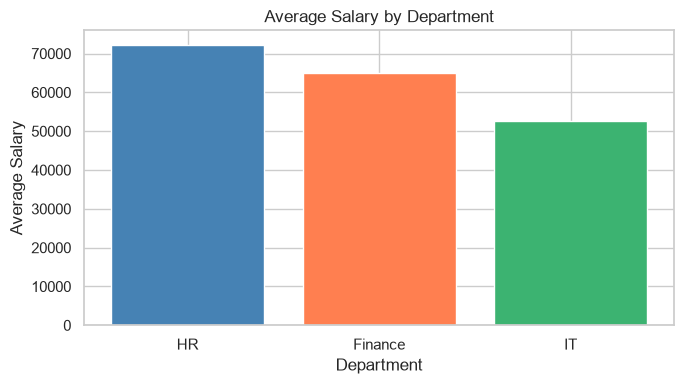

In [34]:
dept_avg = employees.groupby('department')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(dept_avg.index, dept_avg.values, color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.tight_layout()
plt.show()

## 35. Seaborn — Box Plot: Salary Distribution by Department

C:\Users\Umair_Anjum\AppData\Local\Temp\ipykernel_14024\1969862445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=employees, x='department', y='salary', palette='Set2')


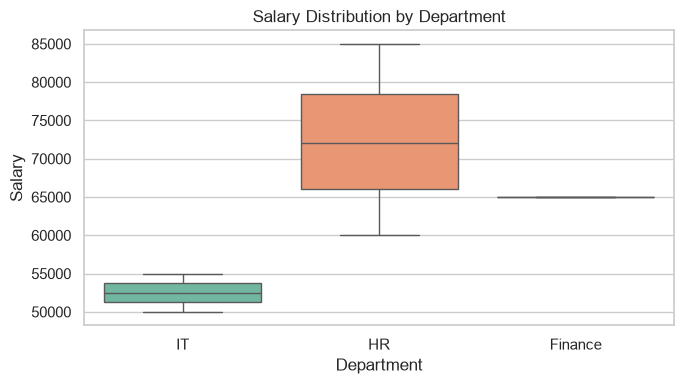

In [35]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=employees, x='department', y='salary', palette='Set2')
plt.title('Salary Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

## 36. Seaborn — Bar Chart: Count by Gender

C:\Users\Umair_Anjum\AppData\Local\Temp\ipykernel_14024\3527508460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=employees, x='gender', palette='pastel')


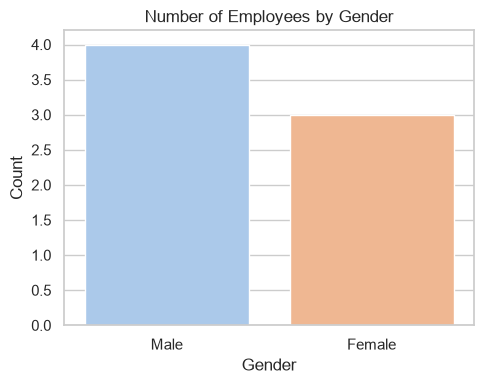

In [36]:
plt.figure(figsize=(5, 4))
sns.countplot(data=employees, x='gender', palette='pastel')
plt.title('Number of Employees by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 37. Seaborn — Scatter Plot: Age vs Salary

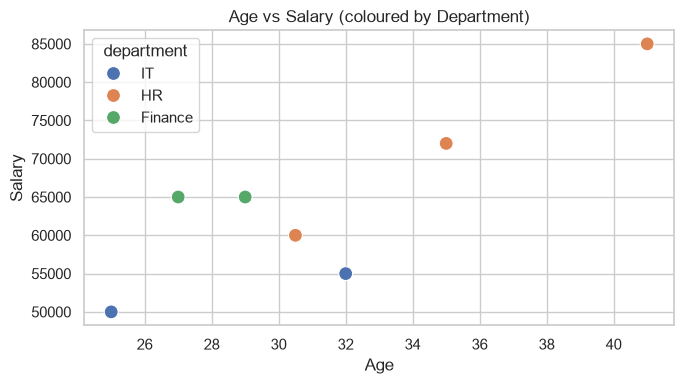

In [37]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=employees, x='age', y='salary', hue='department', s=100)
plt.title('Age vs Salary (coloured by Department)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

## 38. Seaborn — Heatmap: Salary Category vs Department

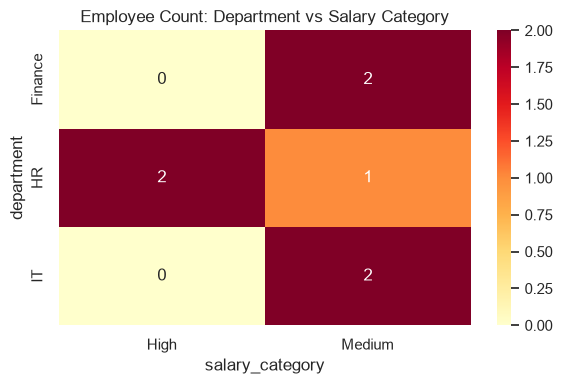

In [38]:
pivot = employees.pivot_table(
    index='department',
    columns='salary_category',
    values='employee_id',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Employee Count: Department vs Salary Category')
plt.tight_layout()
plt.show()

## 39. Matplotlib — Histogram: Age Distribution

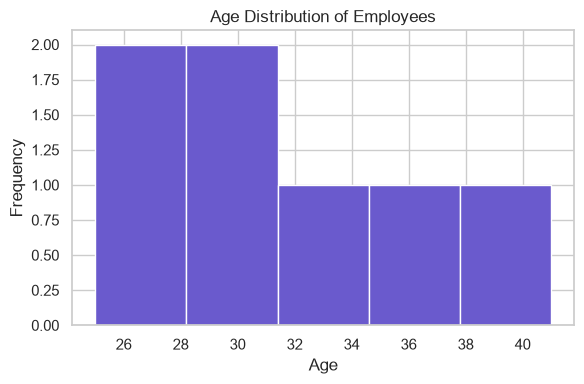

In [39]:
plt.figure(figsize=(6, 4))
plt.hist(employees['age'], bins=5, color='slateblue', edgecolor='white')
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 40. Final Dataset

In [40]:
final = employees[[
    'employee_id', 'name', 'age', 'gender',
    'department', 'salary', 'monthly_salary',
    'salary_category', 'age_group'
]].copy()

print('=== FINAL CLEANED DATASET ===')
print(final.to_string(index=False))

print('\n=== DEPARTMENT SUMMARY ===')
print(department_summary.to_string(index=False))

print('\n=== GENDER SUMMARY ===')
print(gender_summary.to_string(index=False))

=== FINAL CLEANED DATASET ===
 employee_id         name  age gender department  salary  monthly_salary salary_category  age_group
         101     Ali Khan 25.0   Male         IT 50000.0     4166.666667          Medium      Young
         102   Sara Ahmed 30.5 Female         HR 60000.0     5000.000000          Medium Mid-career
         103   Ahmed Raza 32.0   Male         IT 55000.0     4583.333333          Medium Mid-career
         104  Fatima Noor 29.0 Female    Finance 65000.0     5416.666667          Medium      Young
         105    Usman Ali 41.0   Male         HR 85000.0     7083.333333            High     Senior
         106 Ayesha Malik 27.0 Female    Finance 65000.0     5416.666667          Medium      Young
         107   Bilal Shah 35.0   Male         HR 72000.0     6000.000000            High Mid-career

=== DEPARTMENT SUMMARY ===
department  employees  average_salary  median_salary  min_salary  max_salary  total_salary
        HR          3    72333.333333        72000.